In [2]:
import numpy as np
import pandas as pd
from scipy.stats import norm

import numpy as np

mu = -1.16/100
x0 = 60.880

keys = [
    "Dec-25","Jan-26","Feb-26","Mar-26","Apr-26","May-26","Jun-26","Jul-26","Aug-26","Sep-26","Oct-26","Nov-26","Dec-26",
    "Jan-27","Feb-27","Mar-27","Apr-27","May-27","Jun-27","Jul-27","Aug-27","Sep-27","Oct-27","Nov-27","Dec-27"
]

values = x0 * np.exp(mu * np.arange(len(keys))) 
futures_curve = {k: round(v, 3) for k, v in zip(keys, values)}

pricing_date = pd.Timestamp("2025-12-08")
S0 = 60.88
sigma = 23/100

def maturity_date(label):
    d0 = pd.to_datetime(label, format="%b-%y")  # 1er jour du mois
    return d0 + pd.offsets.MonthEnd(0)

def build_strip_df(curve, pricing_date, start="Jan-26", end="Dec-27"):
    s = pd.Series(curve).rename("F0")
    idx = pd.to_datetime(s.index, format="%b-%y")
    df = pd.DataFrame({"label": s.index, "F0": s.values}, index=idx).sort_index()

    start_dt = pd.to_datetime(start, format="%b-%y")
    end_dt = pd.to_datetime(end, format="%b-%y")
    df = df.loc[(df.index >= start_dt) & (df.index <= end_dt)].copy()

    df["maturity"] = [maturity_date(lbl) for lbl in df["label"]]
    df["T"] = (df["maturity"] - pricing_date).dt.days / 365.0
    return df

def implied_carry_b(df, S0):
    return np.log(df["F0"] / S0) / df["T"]

def mc_strip_call_payoff_spot(df, S0, sigma, mu, K, r, n_sims=200000, seed=42):
    rng = np.random.default_rng(seed)
    T = df["T"].to_numpy()
    K = np.asarray(K)
    m = len(df)

    Z_mat = rng.standard_normal((n_sims, m))
    drift = (mu - 0.5 * sigma**2) * T
    volterm = sigma * np.sqrt(T)

    ST = S0 * np.exp(drift[None, :] + volterm[None, :] * Z_mat)
    payoff_mat = np.maximum(ST - K[None, :], 0.0)        

    disc = np.exp(-r * T)                                 
    payoff_pv_mat = payoff_mat * disc[None, :]            

    strip_payoff_pv = payoff_pv_mat.sum(axis=1)            

    out = df.copy()
    out["K"] = K
    out["E_payoff_at_T"] = payoff_mat.mean(axis=0)         
    out["E_payoff_PV"]   = payoff_pv_mat.mean(axis=0)     

    return out, strip_payoff_pv, strip_payoff_pv.mean()

df = build_strip_df(futures_curve, pricing_date, start="Jan-26", end="Dec-27")
df["b_implied"] = implied_carry_b(df, S0)

K = df["F0"].to_numpy()


r = 5/100
res, strip_payoffs_pv, E_strip_pv = mc_strip_call_payoff_spot(df, S0, sigma, mu, K, r, n_sims=200000, seed=7)

print(res[["label", "F0", "T", "b_implied", "E_payoff_at_T", "E_payoff_PV"]])
print("PV moyen du strip =", E_strip_pv)


             label      F0         T  b_implied  E_payoff_at_T  E_payoff_PV
2026-01-01  Jan-26  60.178  0.147945  -0.078393       2.446516     2.428485
2026-02-01  Feb-26  59.484  0.224658  -0.103256       3.284968     3.248274
2026-03-01  Mar-26  58.798  0.309589  -0.112397       4.047453     3.985283
2026-04-01  Apr-26  58.120  0.391781  -0.118420       4.773530     4.680931
2026-05-01  May-26  57.449  0.476712  -0.121682       5.486844     5.357608
2026-06-01  Jun-26  56.787  0.558904  -0.124525       6.145563     5.976202
2026-07-01  Jul-26  56.132  0.643836  -0.126117       6.789982     6.574881
2026-08-01  Aug-26  55.485  0.728767  -0.127327       7.397021     7.132337
2026-09-01  Sep-26  54.845  0.810959  -0.128729       7.979320     7.662247
2026-10-01  Oct-26  54.212  0.895890  -0.129483       8.593496     8.217049
2026-11-01  Nov-26  53.587  0.978082  -0.130458       9.101723     8.667320
2026-12-01  Dec-26  52.969  1.063014  -0.130946       9.607126     9.109833
2027-01-01  

In [3]:
def simulate_ST(df, S0, sigma, mu, n_sims=200000, seed=7):
    rng = np.random.default_rng(seed)
    T = df["T"].to_numpy()
    m = len(df)
    
    Z = rng.standard_normal((n_sims, m))
    drift = (mu - 0.5 * sigma**2) * T
    volterm = sigma * np.sqrt(T)

    ST = S0 * np.exp(drift[None, :] + volterm[None, :] * Z)
    return ST

n_sims = 200000
seed = 7
ST = simulate_ST(df, S0=S0, sigma=sigma, mu=mu, n_sims=n_sims, seed=seed)

labels = df["label"].to_numpy()
F0 = df["F0"].to_numpy()  

q_ST = np.quantile(ST, [0.05, 0.50, 0.95], axis=0)
df_sans_couverture = pd.DataFrame({
    "label": labels,
    "E[ST]": ST.mean(axis=0),
    "ST_q05": q_ST[0],
    "ST_q50": q_ST[1],
    "ST_q95": q_ST[2],
})

print("=== Sans couverture ===")
print(df_sans_couverture)


=== Sans couverture ===
     label      E[ST]     ST_q05     ST_q50     ST_q95
0   Jan-26  60.773534  52.311006  60.550704  69.998307
1   Feb-26  60.728206  50.440726  60.383278  72.218870
2   Mar-26  60.627545  48.686544  60.132867  74.201324
3   Apr-26  60.570511  47.314508  59.939774  76.023683
4   May-26  60.546706  46.029059  59.805590  77.652205
5   Jun-26  60.522439  44.992895  59.637366  79.096375
6   Jul-26  60.446246  43.887509  59.410876  80.564694
7   Aug-26  60.390244  42.947104  59.269081  81.811451
8   Sep-26  60.312848  41.949420  59.009896  83.129215
9   Oct-26  60.295426  41.118168  58.915150  84.328373
10  Nov-26  60.200158  40.423759  58.662044  85.248063
11  Dec-26  60.088100  39.658906  58.406757  86.231633
12  Jan-27  60.065168  38.890576  58.270639  87.418249
13  Feb-27  60.044438  38.197275  58.139164  88.399710
14  Mar-27  59.989357  37.496205  57.937406  89.563140
15  Apr-27  59.891375  37.016416  57.666799  90.301704
16  May-27  59.850281  36.364105  57.5671

In [4]:
E_ST_monthly = ST.mean(axis=0)
F_swap_roll = pd.Series(E_ST_monthly, index=labels).expanding().mean().to_numpy()

df_avec_swap = pd.DataFrame({
    "label": labels,
    "F0": F0,
    "F_swap_roll": F_swap_roll
})

print("\n=== Avec rolling swap (moyenne cumulée) ===")
print(df_avec_swap)


=== Avec rolling swap (moyenne cumulée) ===
     label      F0  F_swap_roll
0   Jan-26  60.178    60.773534
1   Feb-26  59.484    60.750870
2   Mar-26  58.798    60.709762
3   Apr-26  58.120    60.674949
4   May-26  57.449    60.649300
5   Jun-26  56.787    60.628157
6   Jul-26  56.132    60.602170
7   Aug-26  55.485    60.575679
8   Sep-26  54.845    60.546475
9   Oct-26  54.212    60.521370
10  Nov-26  53.587    60.492169
11  Dec-26  52.969    60.458497
12  Jan-27  52.358    60.428241
13  Feb-27  51.754    60.400826
14  Mar-27  51.157    60.373395
15  Apr-27  50.567    60.343269
16  May-27  49.984    60.314269
17  Jun-27  49.408    60.288066
18  Jul-27  48.838    60.254644
19  Aug-27  48.275    60.226043
20  Sep-27  47.718    60.195378
21  Oct-27  47.167    60.165494
22  Nov-27  46.624    60.136991
23  Dec-27  46.086    60.108001


Je prends JetBlue comme compagnie réelle : son rapport annuel indique 853 millions de gallons consommés en 2024 (≈ consommation moyenne mensuelle = 853e6/12).
(On convertit en barils via 42 gal/baril pour être cohérent avec tes prix $/bbl ; et on traite le crude comme proxy du jet fuel — crack spread ignoré.)

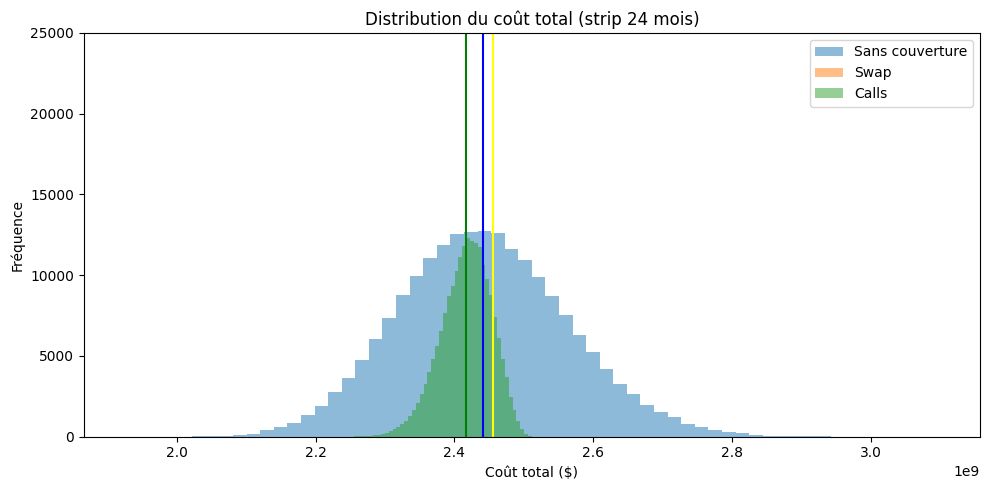

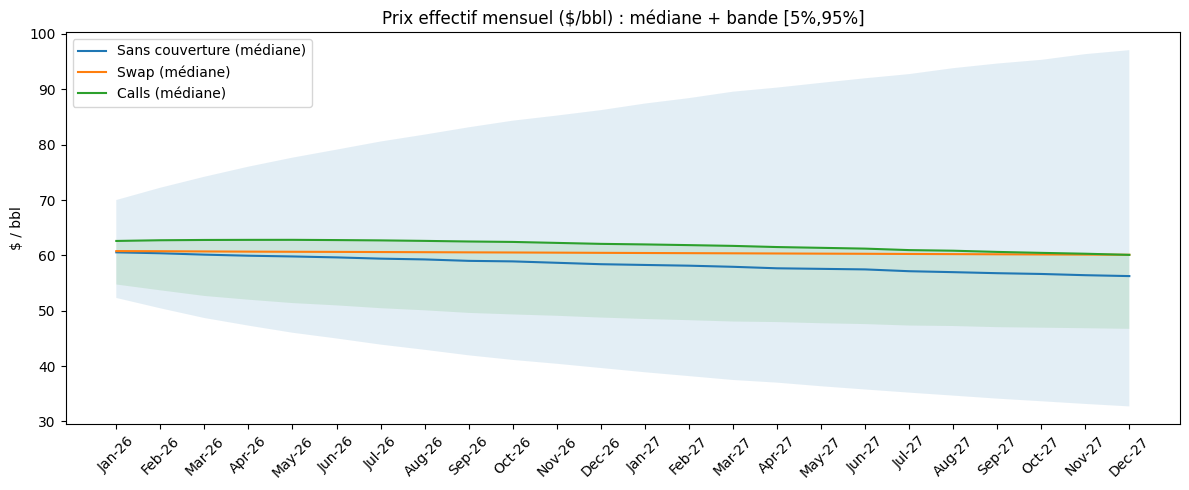


=== Synthèse (coût total + risk) ===
                              mean           std         VaR95        CVaR95  \
strategy                                                                       
Sans couverture       2.441530e+09  1.222182e+08  2.648989e+09  2.707557e+09   
Swap (rolling fixed)  2.455113e+09  0.000000e+00  2.455113e+09  2.455113e+09   
Strip de calls        2.416462e+09  3.663546e+07  2.471859e+09  2.481715e+09   

                               p99  mean_per_bbl  std_per_bbl  VaR95_per_bbl  \
strategy                                                                       
Sans couverture       2.744722e+09     60.108001     3.008888      65.215432   
Swap (rolling fixed)  2.455113e+09     60.442398     0.000000      60.442398   
Strip de calls        2.488149e+09     59.490851     0.901928      60.854665   

                      CVaR95_per_bbl  p99_per_bbl  
strategy                                           
Sans couverture            66.657315    67.572281  
Swap

In [12]:
import matplotlib.pyplot as plt


Q_gal_month = 853e6 / 12
Q_bbl_month = Q_gal_month / 42.0

def risk_metrics(x, alpha=0.95):
    """
    x = array de coûts (1 valeur par simulation), en $ (plus haut = pire).
    VaR_alpha = quantile alpha (ex: 95% => "pire coût à 95%")
    CVaR_alpha = moyenne conditionnelle au-delà de la VaR (pire queue).
    """
    x = np.asarray(x)
    q = np.quantile(x, [0.01, 0.05, 0.50, alpha, 0.99])
    var_a = q[3]
    cvar_a = x[x >= var_a].mean()
    return {
        "mean": x.mean(),
        "std": x.std(ddof=1),
        "p01": q[0],
        "p05": q[1],
        "p50": q[2],
        f"VaR{int(alpha*100)}": var_a,
        f"CVaR{int(alpha*100)}": cvar_a,
        "p99": q[4],
    }

def compare_strategies(ST, df, labels, F_swap_roll, res_calls, Q_bbl_month,
                      alpha=0.95, show_plots=True):
    """
    - Sans couverture: prix = ST (matrice simulée) ; "futures" = E[ST] (pour les stats de moyenne)
    - Swap: prix fixe par mois = F_swap_roll (moyenne cumulée de E[ST])
    - Strip de calls: prix effectif par mois = min(ST, K) + prime
      avec K = F0 et prime = E_payoff_PV (tes premiums par mois)
    """

    ST = np.asarray(ST)                         # (n_sims, m)
    n_sims, m = ST.shape
    labels = np.asarray(labels)

    K = df["F0"].to_numpy()                     # (m,)

    # premiums (par mois) -> aligne sur labels
    prem = (res_calls.reset_index(drop=False)
                    .set_index("label")
                    .loc[labels, "E_payoff_PV"]
                    .to_numpy())                # (m,)

    unit_unhedged = ST
    unit_swap = np.broadcast_to(F_swap_roll[None, :], ST.shape)
    unit_calls = np.minimum(ST, K[None, :]) + prem[None, :]   # <- ta NB

    monthly_unhedged = unit_unhedged * Q_bbl_month
    monthly_swap     = unit_swap     * Q_bbl_month
    monthly_calls    = unit_calls    * Q_bbl_month

    total_unhedged = monthly_unhedged.sum(axis=1)
    total_swap     = monthly_swap.sum(axis=1)
    total_calls    = monthly_calls.sum(axis=1)

    V_total_bbl = Q_bbl_month * m

    rows = []
    for name, tot in [
        ("Sans couverture", total_unhedged),
        ("Swap (rolling fixed)", total_swap),
        ("Strip de calls", total_calls),
    ]:
        met = risk_metrics(tot, alpha=alpha)
        met_per_bbl = {k+"_per_bbl": v / V_total_bbl for k, v in met.items()}
        rows.append({"strategy": name, **met, **met_per_bbl})

    summary_total = pd.DataFrame(rows).set_index("strategy")

    def tail_mean(x, q=0.95):
        thr = np.quantile(x, q)
        return x[x >= thr].mean()

    worst5 = pd.DataFrame({
        "Worst 5% mean total cost ($)": [
            tail_mean(total_unhedged, 0.95),
            tail_mean(total_swap, 0.95),
            tail_mean(total_calls, 0.95),
        ],
        "Worst 5% mean total cost ($/bbl)": [
            tail_mean(total_unhedged, 0.95)/V_total_bbl,
            tail_mean(total_swap, 0.95)/V_total_bbl,
            tail_mean(total_calls, 0.95)/V_total_bbl,
        ],
    }, index=["Sans couverture", "Swap (rolling fixed)", "Strip de calls"])

    max_unit = pd.DataFrame({
        "q95 of max monthly unit price ($/bbl)": [
            np.quantile(unit_unhedged.max(axis=1), 0.95),
            np.quantile(unit_swap.max(axis=1),     0.95),
            np.quantile(unit_calls.max(axis=1),    0.95),
        ],
        "q99 of max monthly unit price ($/bbl)": [
            np.quantile(unit_unhedged.max(axis=1), 0.99),
            np.quantile(unit_swap.max(axis=1),     0.99),
            np.quantile(unit_calls.max(axis=1),    0.99),
        ],
    }, index=["Sans couverture", "Swap (rolling fixed)", "Strip de calls"])

    idx_best = total_unhedged <= np.quantile(total_unhedged, 0.05)
    upside = pd.DataFrame({
        "Avg total cost in best-5% price scenarios ($)": [
            total_unhedged[idx_best].mean(),
            total_swap[idx_best].mean(),
            total_calls[idx_best].mean(),
        ],
        "Avg total cost in best-5% price scenarios ($/bbl)": [
            total_unhedged[idx_best].mean()/V_total_bbl,
            total_swap[idx_best].mean()/V_total_bbl,
            total_calls[idx_best].mean()/V_total_bbl,
        ],
    }, index=["Sans couverture", "Swap (rolling fixed)", "Strip de calls"])

    if show_plots:
        plt.figure(figsize=(10, 5))
        plt.axvline(x=total_unhedged.mean(),color= "blue")
        plt.axvline(x=total_calls.mean(),color= "green")
        plt.axvline(x=total_swap.mean(),color= "yellow")
        plt.hist(total_unhedged, bins=60, alpha=0.5, label="Sans couverture")
        plt.hist(total_swap,     bins=60, alpha=0.5, label="Swap")
        plt.hist(total_calls,    bins=60, alpha=0.5, label="Calls")
        plt.title("Distribution du coût total (strip 24 mois)")
        plt.xlabel("Coût total ($)")
        plt.ylabel("Fréquence")
        plt.ylim(0, 25000) 
        plt.legend()
        plt.tight_layout()
        plt.show()

        def band(mat_unit, name):
            q05 = np.quantile(mat_unit, 0.05, axis=0)
            q50 = np.quantile(mat_unit, 0.50, axis=0)
            q95 = np.quantile(mat_unit, 0.95, axis=0)
            return pd.DataFrame({"label": labels, "q05": q05, "q50": q50, "q95": q95}).assign(strategy=name)

        prof = pd.concat([
            band(unit_unhedged, "Sans couverture"),
            band(unit_swap,     "Swap"),
            band(unit_calls,    "Calls"),
        ], ignore_index=True)

        plt.figure(figsize=(12, 5))
        for strat in ["Sans couverture", "Swap", "Calls"]:
            tmp = prof[prof["strategy"] == strat]
            plt.plot(tmp["label"], tmp["q50"], label=f"{strat} (médiane)")
            plt.fill_between(tmp["label"], tmp["q05"], tmp["q95"], alpha=0.12)
        plt.xticks(rotation=45)
        plt.title("Prix effectif mensuel ($/bbl) : médiane + bande [5%,95%]")
        plt.ylabel("$ / bbl")
        plt.tight_layout()
        plt.legend()
        plt.show()

    return summary_total, worst5, max_unit, upside

summary_total, worst5, max_unit, upside, = compare_strategies(
    ST=ST,
    df=df,
    labels=labels,
    F_swap_roll=F_swap_roll,
    res_calls=res,          
    Q_bbl_month=Q_bbl_month,
    alpha=0.95,
    show_plots=True
)

print("\n=== Synthèse (coût total + risk) ===")
print(summary_total[[
    "mean","std","VaR95","CVaR95","p99",
    "mean_per_bbl","std_per_bbl","VaR95_per_bbl","CVaR95_per_bbl","p99_per_bbl"
]])

print("\n=== Protection - pire 5% (queue) ===")
print(worst5)

print("\n=== Protection - cap / worst-month ($/bbl) ===")
print(max_unit)

print("\n=== Upside (best 5% scénarios prix bas) ===")
print(upside)



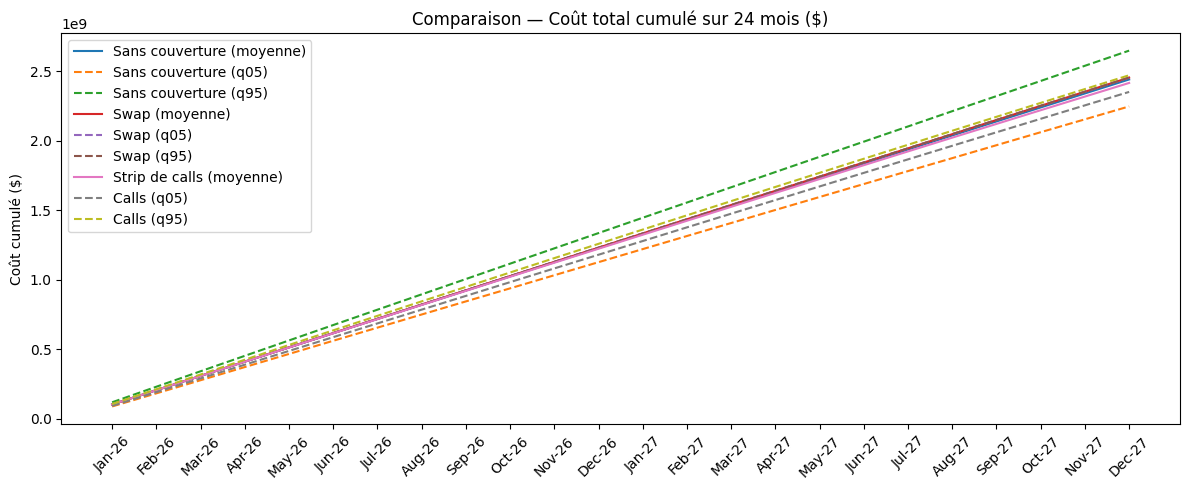

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

labels = np.asarray(labels)
K = df["F0"].to_numpy()

prem = (res.reset_index(drop=False)
          .set_index("label")
          .loc[labels, "E_payoff_PV"]
          .to_numpy())

unit_unhedged = ST
unit_swap     = np.broadcast_to(F_swap_roll[None, :], ST.shape)
unit_calls    = np.minimum(ST, K[None, :]) + prem[None, :] 

monthly_unhedged = unit_unhedged * Q_bbl_month
monthly_swap     = unit_swap     * Q_bbl_month
monthly_calls    = unit_calls    * Q_bbl_month

cum_unhedged = np.cumsum(monthly_unhedged, axis=1)
cum_swap     = np.cumsum(monthly_swap, axis=1)
cum_calls    = np.cumsum(monthly_calls, axis=1)

def summary_curve(cum_mat):
    mean = cum_mat.mean(axis=0)
    q05  = np.quantile(cum_mat, 0.05, axis=0)
    q95  = np.quantile(cum_mat, 0.95, axis=0)
    return mean, q05, q95

m_unh, q05_unh, q95_unh = summary_curve(cum_unhedged)
m_swp, q05_swp, q95_swp = summary_curve(cum_swap)
m_cal, q05_cal, q95_cal = summary_curve(cum_calls)

plt.figure(figsize=(12,5))

plt.plot(labels, m_unh, label="Sans couverture (moyenne)")
plt.plot(labels, q05_unh, linestyle="--", label="Sans couverture (q05)")
plt.plot(labels, q95_unh, linestyle="--", label="Sans couverture (q95)")

plt.plot(labels, m_swp, label="Swap (moyenne)")
plt.plot(labels, q05_swp, linestyle="--", label="Swap (q05)")
plt.plot(labels, q95_swp, linestyle="--", label="Swap (q95)")

plt.plot(labels, m_cal, label="Strip de calls (moyenne)")
plt.plot(labels, q05_cal, linestyle="--", label="Calls (q05)")
plt.plot(labels, q95_cal, linestyle="--", label="Calls (q95)")

plt.title("Comparaison — Coût total cumulé sur 24 mois ($)")
plt.ylabel("Coût cumulé ($)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# X axis as real dates (better for zoom + range slider)
x = pd.to_datetime(labels, format="%b-%y")

scale = 1e6  # show everything in millions

fig = go.Figure()

def add_strategy(mean, q05, q95, name):
    fig.add_trace(go.Scatter(
        x=x, y=np.array(mean)/scale,
        mode="lines+markers",
        name=f"{name} (moyenne)",
        hovertemplate="%{x|%b-%y}<br>" + f"{name} moyenne: " + "%{y:,.2f} M$<extra></extra>"
    ))
    # Put q05/q95 in the legend but hidden by default (click to show)
    fig.add_trace(go.Scatter(
        x=x, y=np.array(q05)/scale,
        mode="lines",
        line=dict(dash="dash"),
        name=f"{name} (q05)",
        visible="legendonly",
        hovertemplate="%{x|%b-%y}<br>" + f"{name} q05: " + "%{y:,.2f} M$<extra></extra>"
    ))
    fig.add_trace(go.Scatter(
        x=x, y=np.array(q95)/scale,
        mode="lines",
        line=dict(dash="dash"),
        name=f"{name} (q95)",
        visible="legendonly",
        hovertemplate="%{x|%b-%y}<br>" + f"{name} q95: " + "%{y:,.2f} M$<extra></extra>"
    ))

add_strategy(m_unh, q05_unh, q95_unh, "Sans couverture")
add_strategy(m_swp, q05_swp, q95_swp, "Swap")
add_strategy(m_cal, q05_cal, q95_cal, "Strip de calls")

fig.update_layout(
    title="Comparaison — Coût total cumulé sur 24 mois (M$)",
    yaxis_title="Coût cumulé (M$)",
    hovermode="x unified",
    legend_title="Clique pour afficher/masquer"
)
fig.update_xaxes(rangeslider_visible=True)

fig.show()


In [67]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

x = pd.to_datetime(labels, format="%b-%y")
scale = 1e6  # en M$

# Convertir en M$
m_unh_m  = np.array(m_unh)  / scale
m_swp_m  = np.array(m_swp)  / scale
m_cal_m  = np.array(m_cal)  / scale

q05_unh_m = np.array(q05_unh) / scale
q95_unh_m = np.array(q95_unh) / scale
q05_swp_m = np.array(q05_swp) / scale
q95_swp_m = np.array(q95_swp) / scale
q05_cal_m = np.array(q05_cal) / scale
q95_cal_m = np.array(q95_cal) / scale

# Écarts (moyennes) vs sans couverture
d_swp = m_swp_m - m_unh_m
d_cal = m_cal_m - m_unh_m

fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
    row_heights=[0.65, 0.35],
    subplot_titles=("Coût cumulé (M$)", "Écart vs Sans couverture (M$)")
)

def add_levels(mean, q05, q95, name):
    fig.add_trace(go.Scatter(
        x=x, y=mean, mode="lines+markers",
        name=f"{name} (moyenne)",
        hovertemplate="%{x|%b-%y}<br>"+f"{name}: "+"%{y:,.2f} M$<extra></extra>"
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=x, y=q05, mode="lines", line=dict(dash="dash"),
        name=f"{name} (q05)", visible="legendonly",
        hovertemplate="%{x|%b-%y}<br>"+f"{name} q05: "+"%{y:,.2f} M$<extra></extra>"
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=x, y=q95, mode="lines", line=dict(dash="dash"),
        name=f"{name} (q95)", visible="legendonly",
        hovertemplate="%{x|%b-%y}<br>"+f"{name} q95: "+"%{y:,.2f} M$<extra></extra>"
    ), row=1, col=1)

add_levels(m_unh_m, q05_unh_m, q95_unh_m, "Sans couverture")
add_levels(m_swp_m, q05_swp_m, q95_swp_m, "Swap")
add_levels(m_cal_m, q05_cal_m, q95_cal_m, "Strip de calls")

# Panneau des écarts
fig.add_trace(go.Scatter(
    x=x, y=d_swp, mode="lines+markers",
    name="Δ Swap − Sans couverture",
    hovertemplate="%{x|%b-%y}<br>Δ Swap: %{y:,.2f} M$<extra></extra>"
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=x, y=d_cal, mode="lines+markers",
    name="Δ Calls − Sans couverture",
    hovertemplate="%{x|%b-%y}<br>Δ Calls: %{y:,.2f} M$<extra></extra>"
), row=2, col=1)

# Ligne y=0 pour lire l'écart facilement
fig.add_hline(y=0, line_dash="dot", row=2, col=1)

fig.update_layout(
    title="Comparaison — Coût total cumulé sur 24 mois (M$) + Écarts",
    hovermode="x unified",
    legend_title="Clique pour afficher/masquer",
)

fig.update_yaxes(title_text="M$", row=1, col=1)
fig.update_yaxes(title_text="Δ M$", row=2, col=1)
fig.update_xaxes(rangeslider_visible=True, row=2, col=1)

fig.show()
